提示: 未安装 umap-learn，将仅生成 PCA 和 t-SNE 图。建议运行 'pip install umap-learn' 获取最佳聚类效果。
正在读取数据并生成混合分子特征...
指纹降维: 1024 -> 1024 (剔除了仅在1-2个分子中出现的低频噪音位)
正在执行降维分析...
正在生成可视化图表...


[21:29:25] DEPRECATION WARNING: please use MorganGenerator
[21:29:25] DEPRECATION WARNING: please use MorganGenerator
[21:29:25] DEPRECATION WARNING: please use MorganGenerator
[21:29:25] DEPRECATION WARNING: please use MorganGenerator
[21:29:25] DEPRECATION WARNING: please use MorganGenerator
[21:29:25] DEPRECATION WARNING: please use MorganGenerator
[21:29:25] DEPRECATION WARNING: please use MorganGenerator
[21:29:25] DEPRECATION WARNING: please use MorganGenerator
[21:29:25] DEPRECATION WARNING: please use MorganGenerator
[21:29:25] DEPRECATION WARNING: please use MorganGenerator
[21:29:25] DEPRECATION WARNING: please use MorganGenerator
[21:29:25] DEPRECATION WARNING: please use MorganGenerator
[21:29:25] DEPRECATION WARNING: please use MorganGenerator
[21:29:25] DEPRECATION WARNING: please use MorganGenerator
[21:29:25] DEPRECATION WARNING: please use MorganGenerator
[21:29:25] DEPRECATION WARNING: please use MorganGenerator
[21:29:25] DEPRECATION WARNING: please use MorganGenerat

可视化图表已保存至: optimized_analysis_visualization.png


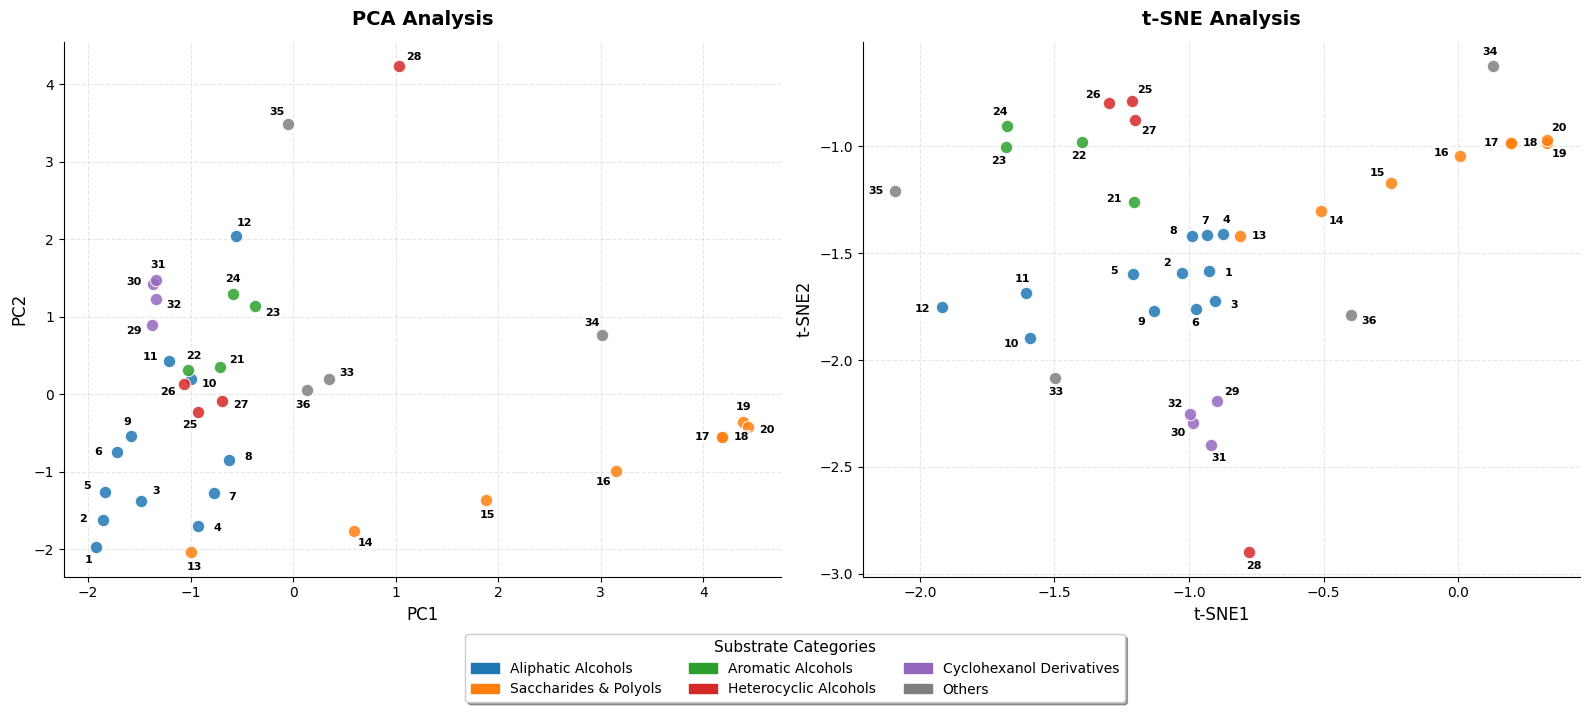

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# 尝试导入 UMAP (如果未安装则跳过)
try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("提示: 未安装 umap-learn，将仅生成 PCA 和 t-SNE 图。建议运行 'pip install umap-learn' 获取最佳聚类效果。")

# ======================== 1. 配置参数 ========================
EXCEL_FILE = "sub.xlsx"      
OUTPUT_PREFIX = "optimized_analysis" 
RANDOM_STATE = 42                   

CATEGORIES = [
    ("Aliphatic Alcohols",          "#1f77b4", range(1, 13)),    
    ("Saccharides & Polyols",       "#ff7f0e", range(13, 21)),   
    ("Aromatic Alcohols",           "#2ca02c", range(21, 25)),   
    ("Heterocyclic Alcohols",       "#d62728", range(25, 29)),   
    ("Cyclohexanol Derivatives",    "#9467bd", range(29, 33)),   
    ("Others",                      "#7f7f7f", range(33, 37)),   
]

def get_category(id_val):
    for name, color, id_range in CATEGORIES:
        if id_val in id_range:
            return name, color
    return "Others", "#7f7f7f"

# ======================== 2. 数据读取与特征工程 ========================
print("正在读取数据并生成混合分子特征...")
df_raw = pd.read_excel(EXCEL_FILE)
unique_subs = df_raw['sub'].drop_duplicates(keep='first').reset_index()
unique_subs.rename(columns={'index': 'original_idx', 'sub': 'smiles'}, inplace=True)
unique_subs['id'] = range(1, len(unique_subs) + 1)

morgan_fps = []
global_descs = []
valid_indices = []

for idx, row in unique_subs.iterrows():
    mol = Chem.MolFromSmiles(row['smiles'])
    if mol is None: continue
    
    # 1. Morgan 指纹
    morgan_fp = np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024))
    morgan_fps.append(morgan_fp)
    
    # 2. 全局描述符 (重原子数, 分子量, TPSA, LogP)
    global_descs.append([
        mol.GetNumHeavyAtoms(),
        Descriptors.MolWt(mol),
        Descriptors.TPSA(mol),
        Descriptors.MolLogP(mol)
    ])
    valid_indices.append(idx)

df = unique_subs.iloc[valid_indices].copy().reset_index(drop=True)
X_morgan = np.array(morgan_fps)
X_global = np.array(global_descs)

# 【核心优化 1】：过滤低频指纹位 (消除底物28 Boc基团的独有特征方差)
# 仅保留在至少 3 个分子中出现的指纹位
col_sums = X_morgan.sum(axis=0)
valid_cols = np.where(col_sums >= 0)[0]
X_morgan_filtered = X_morgan[:, valid_cols]
print(f"指纹降维: 1024 -> {len(valid_cols)} (剔除了仅在1-2个分子中出现的低频噪音位)")

# 标准化全局描述符
scaler = StandardScaler()
X_global_scaled = scaler.fit_transform(X_global)

# 拼接特征
X_combined = np.hstack([X_morgan_filtered, X_global_scaled])

# ======================== 3. 降维分析 (PCA, t-SNE, UMAP) ========================
print("正在执行降维分析...")

# --- PCA ---
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_combined)
df['pca_x'], df['pca_y'] = X_pca[:, 0], X_pca[:, 1]

# 【核心优化 2】：t-SNE 预降维 (解决高维稀疏导致的离散问题)
# 先用 TruncatedSVD 将特征降至 30 维，再输入 t-SNE
svd = TruncatedSVD(n_components=30, random_state=RANDOM_STATE)
X_svd = svd.fit_transform(X_combined)

# 【核心优化 3】：调整 Perplexity 至 25 (促进全局类别聚集)
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, 
            max_iter=1000, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_svd) # 注意：输入的是 SVD 降维后的数据
df['tsne_x'], df['tsne_y'] = X_tsne[:, 0], X_tsne[:, 1]

# --- UMAP (备选，通常聚类效果最好) ---
if HAS_UMAP:
    reducer = umap.UMAP(n_components=2, n_neighbors=10, min_dist=0.3, random_state=RANDOM_STATE)
    X_umap = reducer.fit_transform(X_svd)
    df['umap_x'], df['umap_y'] = X_umap[:, 0], X_umap[:, 1]

df['category'] = df['id'].apply(lambda x: get_category(x)[0])
df['color']    = df['id'].apply(lambda x: get_category(x)[1])
df.to_excel(f"{OUTPUT_PREFIX}_results.xlsx", index=False)

# ======================== 4. 智能防重叠标签算法 ========================
def calculate_label_positions(x, y, offset_dist):
    n = len(x)
    x_range = max(x) - min(x) if max(x) != min(x) else 1
    y_range = max(y) - min(y) if max(y) != min(y) else 1
    x_norm = (x - min(x)) / x_range
    y_norm = (y - min(y)) / y_range
    offset_x_dist = offset_dist * x_range
    offset_y_dist = offset_dist * y_range
    label_x, label_y = np.zeros(n), np.zeros(n)
    
    for i in range(n):
        coincident_indices = [j for j in range(n) if i != j and abs(x[i] - x[j]) < 1e-5 and abs(y[i] - y[j]) < 1e-5]
        if len(coincident_indices) > 0:
            angle = np.pi if df.iloc[i]['id'] < df.iloc[coincident_indices[0]]['id'] else 0.0
        else:
            angles = np.linspace(0, 2 * np.pi, 72, endpoint=False)
            min_repulsion = np.inf
            best_angle = 0
            dists = np.sqrt((x_norm - x_norm[i])**2 + (y_norm - y_norm[i])**2)
            nearest_indices = np.argsort(dists)[1:min(8, n)]
            for ang in angles:
                cand_x = x_norm[i] + offset_dist * np.cos(ang)
                cand_y = y_norm[i] + offset_dist * np.sin(ang)
                repulsion = sum(1.0 / ((cand_x - x_norm[j])**2 + (cand_y - y_norm[j])**2 + 1e-6) for j in nearest_indices)
                if repulsion < min_repulsion:
                    min_repulsion = repulsion
                    best_angle = ang
            angle = best_angle
        label_x[i] = x[i] + offset_x_dist * np.cos(angle)
        label_y[i] = y[i] + offset_y_dist * np.sin(angle)
    return label_x, label_y

def plot_labels(ax, x, y, labels, offset_dist=0.04, fontsize=8):
    lx, ly = calculate_label_positions(x, y, offset_dist)
    for i in range(len(labels)):
        ax.text(lx[i], ly[i], str(labels[i]), fontsize=fontsize, fontweight='bold', 
                ha='center', va='center', zorder=5,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1.2))

# ======================== 5. 绘图主逻辑 ========================
print("正在生成可视化图表...")
n_plots = 3 if HAS_UMAP else 2
fig, axes = plt.subplots(1, n_plots, figsize=(8 * n_plots, 7))
if n_plots == 2: axes = list(axes) # 确保可迭代

legend_handles = [mpatches.Patch(color=color, label=name) for name, color, _ in CATEGORIES]

plot_configs = [
    (axes[0], 'pca_x', 'pca_y', 'PCA Analysis', 'PC1', 'PC2'),
    (axes[1], 'tsne_x', 'tsne_y', 't-SNE Analysis', 't-SNE1', 't-SNE2'),
]
if HAS_UMAP:
    plot_configs.append((axes[2], 'umap_x', 'umap_y', 'UMAP Analysis', 'UMAP1', 'UMAP2'))

for ax, x_col, y_col, title, xlabel, ylabel in plot_configs:
    for name, color, id_range in CATEGORIES:
        mask = df['id'].isin(id_range)
        ax.scatter(df.loc[mask, x_col], df.loc[mask, y_col],
                   c=color, s=80, alpha=0.85, edgecolors='white', linewidths=0.8, zorder=3)
    
    # 动态调整标签偏移距离
    offset = 0.05 if 'pca' in x_col else 0.08 
    plot_labels(ax, df[x_col].values, df[y_col].values, df['id'].values, offset_dist=0.03)
    
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.legend(handles=legend_handles, loc='lower center', ncol=3, fontsize=10,
           frameon=True, fancybox=True, shadow=True, bbox_to_anchor=(0.5, -0.02),
           title='Substrate Categories', title_fontsize=11)

plt.tight_layout(rect=[0, 0.08, 1, 1])
fig_file = f"{OUTPUT_PREFIX}_visualization.png"
plt.savefig(fig_file, dpi=300, bbox_inches='tight')
print(f"可视化图表已保存至: {fig_file}")
plt.show()